# Activity 2: Horospheres and a Two-Layer HBNN

<p align="center">
  <a href="https://github.com/GitZH-Chen/MLSS-RDL-Tutorial">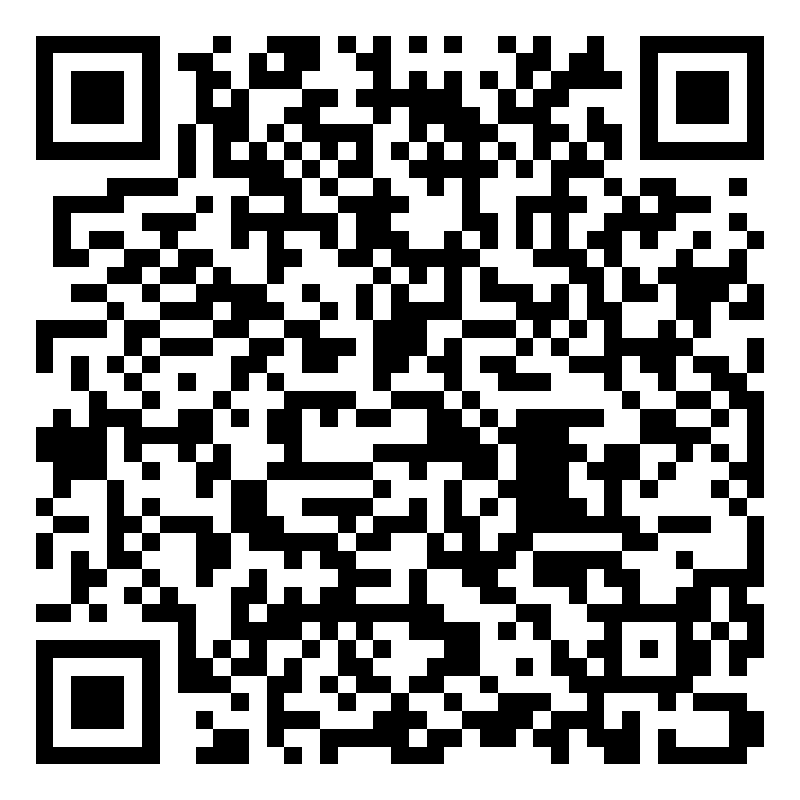</a>
</p>
<p align="center"><a href="https://github.com/GitZH-Chen/MLSS-RDL-Tutorial">https://github.com/GitZH-Chen/MLSS-RDL-Tutorial</a></p>

Tasks:

1. visualize horospheres in the Poincaré and Lorentz models.
2. train a two-layer HBNN, consisting of a Busemann fully connected (BFC) layer and a Busemann multinomial logistic regression (BMLR) layer, on a synthetic classification dataset.

## Mathematical preliminaries

For curvature $K<0$, we use the Poincaré and Lorentz models.

$$
\begin{aligned}
\mathbb{P}^n_K
&=\left\{x\in\mathbb{R}^n\mid \lVert x\rVert^2<-1/K\right\},\\[4pt]
\mathbb{L}^n_K
&=\left\{x=[x_t,x_s^\top]^\top\in\mathbb{R}^{n+1}\mid \langle x,x\rangle_{ℒ}=1/K,\ x_t>0\right\},\\[4pt]
\langle x,y\rangle_{ℒ}
&=-x_ty_t+\langle x_s,y_s\rangle,\qquad
ℋ^n_K\in\left\{\mathbb{P}^n_K,\mathbb{L}^n_K\right\}.
\end{aligned}
$$

Let $\gamma$ be a unit-speed geodesic ray. Its **Busemann function** is shown below. In Euclidean space, it reduces to the inner product up to sign.

$$
B^\gamma(x)=\lim_{t\to\infty}\left(d(x,\gamma(t))-t\right).
$$

In Euclidean space,

$$
\gamma(t)=tv\quad\Longrightarrow\quad
B^v(x)=-\langle x,v\rangle,\qquad -B^v(x)=\langle v,x\rangle.
$$

For a unit direction $v\in\mathbb{S}^{n-1}$, the closed forms used in HBNN are

$$
\begin{aligned}
\mathbb{P}^n_K:\quad B^v(x)
&=\frac{1}{\sqrt{-K}}\log\left(
\frac{\lVert v-\sqrt{-K}x\rVert^2}{1+K\lVert x\rVert^2}
\right),\\[6pt]
\mathbb{L}^n_K:\quad B^v(x)
&=\frac{1}{\sqrt{-K}}\log\left(
\sqrt{-K}\left(x_t-\langle x_s,v\rangle\right)
\right).
\end{aligned}
$$

A **horosphere** is a level set.

$$
H^v_\tau=\left\{x\in ℋ^n_K\mid B^v(x)=\tau\right\}.
$$

The correspondence used by HBNN is summarized below.

| Notion | Euclidean $\mathbb{R}^{n}$&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | Hyperbolic $ℋ^{n}_{K}$&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |
|:--|:--|:--|
| Inner product | $\langle v,x\rangle$ | $-B^{v}(x)$ |
| Hyperplane | $\widetilde{H}^{v}_{\tau}=\{x\in\mathbb{R}^{n}\mid\langle x,v\rangle=\tau\}$ | $H^{v}_{\tau}=\{x\in ℋ^{n}_{K}\mid B^{v}(x)=\tau\}$ |
| Parallel hyperplanes | Parallel $\{\widetilde{H}^{v}_{\tau}\}_{\tau}$ for fixed $v$ | Equidistant $\{H^{v}_{\tau}\}_{\tau}$ for fixed $v$ |
| Logit $u_k(x)$ | $\alpha_k\langle v_k,x\rangle+b_k$ | $-\alpha_kB^{v_k}(x)+b_k$ |

## References

- Ziheng Chen, Bernhard Schölkopf, and Nicu Sebe. **Hyperbolic Busemann Neural Networks.** CVPR 2026. [Paper](https://arxiv.org/abs/2602.18858) · [Code](https://github.com/GitZH-Chen/HBNN)

## Setup


In [ ]:
%pip -q install geoopt==0.5.1

!test -d /content/mlss_hbnn || git clone -q https://github.com/GitZH-Chen/HBNN.git /content/mlss_hbnn
!git -C /content/mlss_hbnn checkout -q d5c79c8eed36a0b7c2f15e9a8fbcd0318216e5b0

In [ ]:
import random
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

warnings.filterwarnings("ignore", category=SyntaxWarning)
sys.path.insert(0, "/content/mlss_hbnn")

from lib.bnn.BFC import BFC
from lib.bnn.BMLR import BMLR
from lib.bnn.Geometry import Stereographic
from lib.bnn.evaluation.vis_horosphere import main as plot_horospheres


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seed(7)
print("PyTorch:", torch.__version__)

## Task 1: Visualize horospheres

We fix $K=-1$ and $v=(1,0)$. Each curve is a level set $B^v(x)=\tau$.

**Predict:** How should horospheres with the same direction differ as $\tau$ changes?

In [ ]:
plot_horospheres()

**Interpret:** In the Poincaré ball, the horospheres are Euclidean circles tangent to the boundary at the same ideal point. In the Lorentz model, they are intersections of the hyperboloid with parallel affine hyperplanes.

## Task 2: Train a two-layer HBNN

The learnable network is

$$
\mathbb{R}^{2}
\xrightarrow{\operatorname{Exp}_{0}}
\mathbb{P}^{2}_{K}
\xrightarrow{\operatorname{BFC}}
\mathbb{P}^{8}_{K}
\xrightarrow{\operatorname{BMLR}}
\mathbb{R}^{3}.
$$

The exponential map embeds the input. The two trainable layers are BFC and BMLR. Their Euclidean and Busemann formulations are compared below.

| Layer | Expression&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | Parameters&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |
|:--|:--|:--|
| Euclidean FC | $y_k=\phi(\langle a_k,x\rangle+b_k),\quad k=1,\ldots,m$ | $a_k\in\mathbb{R}^n,\ b_k\in\mathbb{R}$ |
| Euclidean MLR | $u_k(x)=\langle a_k,x\rangle+b_k,\quad p(y=k\mid x)=\dfrac{e^{u_k(x)}}{\sum_{j=1}^{C}e^{u_j(x)}}$ | $a_k\in\mathbb{R}^n,\ b_k\in\mathbb{R},\quad k=1,\ldots,C$ |
| BFC (Poincaré) | $u_k(x)=\phi(-\alpha_kB^{v_k}(x)+b_k),\quad \omega_k=\dfrac{\sinh(\sqrt{-K}u_k(x))}{\sqrt{-K}},\quad y=\dfrac{\omega}{1+\sqrt{1-K\lVert\omega\rVert^2}}$ | $\alpha_k>0,\ v_k\in\mathbb{S}^{n-1},\ b_k\in\mathbb{R},\quad k=1,\ldots,m$ |
| BMLR | $u_k(x)=-\alpha_kB^{v_k}(x)+b_k,\quad p(y=k\mid x)=\dfrac{e^{u_k(x)}}{\sum_{j=1}^{C}e^{u_j(x)}}$ | $\alpha_k>0,\ v_k\in\mathbb{S}^{n-1},\ b_k\in\mathbb{R},\quad k=1,\ldots,C$ |

### Generate a synthetic dataset

In [ ]:
centers = torch.tensor([[-1.5, -0.8], [1.5, -0.8], [0.0, 1.5]])
features = torch.cat([center + 0.55 * torch.randn(120, 2) for center in centers])
labels = torch.arange(3).repeat_interleave(120)

permutation = torch.randperm(len(features))
train_ids = permutation[:280]
validation_ids = permutation[280:]
x_train, y_train = features[train_ids], labels[train_ids]
x_validation, y_validation = features[validation_ids], labels[validation_ids]

plt.figure(figsize=(5, 4))
plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train, cmap="viridis", s=22)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Synthetic training data")
plt.show()

### Define the network

**Predict:** For a batch of 8 samples and 3 classes, what is the shape of the BMLR output?

In [ ]:
class TwoLayerHBNN(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=8, n_classes=3, curvature=-1.0):
        super().__init__()
        self.manifold = Stereographic(K=curvature)
        self.hidden = BFC(
            in_dim=input_dim,
            out_dim=hidden_dim,
            metric="poincare",
            K=curvature,
            act="relu",
        )
        self.classifier = BMLR(
            n_classes=n_classes,
            dim=hidden_dim,
            metric="poincare",
            K=curvature,
        )

    def forward(self, x):
        x_hyperbolic = self.manifold.exp0(0.25 * x)
        hidden_hyperbolic = self.hidden(x_hyperbolic)
        return self.classifier(hidden_hyperbolic)


model = TwoLayerHBNN()
print(model)

### Train

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.03)
criterion = nn.CrossEntropyLoss()
loss_history = []
validation_accuracy_history = []

for epoch in range(151):
    model.train()
    optimizer.zero_grad()
    logits = model(x_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        validation_predictions = model(x_validation).argmax(dim=1)
        validation_accuracy = (
            validation_predictions == y_validation
        ).float().mean().item()

    loss_history.append(loss.item())
    validation_accuracy_history.append(validation_accuracy)

    if epoch % 30 == 0:
        print(
            f"Epoch {epoch:3d} | loss {loss.item():.4f} | "
            f"validation accuracy {validation_accuracy:.3f}"
        )

### Evaluate and visualize

In [ ]:
model.eval()
with torch.no_grad():
    train_accuracy = (
        model(x_train).argmax(dim=1) == y_train
    ).float().mean().item()
    validation_accuracy = (
        model(x_validation).argmax(dim=1) == y_validation
    ).float().mean().item()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(loss_history)
axes[0].set(xlabel="Epoch", ylabel="Cross-entropy", title="Training loss")
axes[1].plot(validation_accuracy_history)
axes[1].set(
    xlabel="Epoch",
    ylabel="Accuracy",
    ylim=(0, 1.02),
    title="Validation accuracy",
)
plt.tight_layout()
plt.show()

print(f"Train accuracy: {train_accuracy:.3f}")
print(f"Validation accuracy: {validation_accuracy:.3f}")

## Takeaways

- Busemann functions generalize Euclidean inner products.
- Horospheres are the hyperbolic counterparts of Euclidean hyperplanes.
- BFC maps hyperbolic features to hyperbolic features.
- BMLR maps hyperbolic features to class logits.
- Both layers can be trained end to end with ordinary PyTorch optimization.